In [5]:
import os
import glob
import pandas as pd
import xml.etree.ElementTree as ET

def xml_to_df(xml_folder):
    data_list = []
    for xml_file in glob.glob(os.path.join(xml_folder, "*.xml")):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        filename = root.find("filename").text
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)

        for obj in root.findall("object"):
            name = obj.find("name").text
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)

            data_list.append([filename, name, width, height, xmin, ymin, xmax, ymax])
    
    column_names = ["filename", "building_name", "img_width", "img_height", "xmin", "ymin", "xmax", "ymax"]
    df = pd.DataFrame(data_list, columns=column_names)
    return df

xml_folder = "annotations/"  
data = xml_to_df(xml_folder)


In [6]:
data.head()

,filename,building_name,img_width,img_height,xmin,ymin,xmax,ymax
0,A_1.JPG,Block A,4032,3024,14,1466,4031,2701
1,A_10.JPG,Block A,4032,3024,346,230,4032,2665
2,A_11.jpg,Block A,4032,3024,278,637,4031,2897
3,A_12.jpg,Block A,4032,3024,14,653,3856,3014
4,A_13.jpg,Block A,4032,3024,433,495,4031,2966


In [7]:
len(data)

101

In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import os
from collections import defaultdict
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## Preprocessing

In [10]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [11]:
class ImageDataset():
    def __init__(self, data, root_dir, transform=None, num_aug=3):
        self.data = data
        self.root_dir = root_dir
        self.original_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.augment_transform = transform  # Augmentation transform
        self.num_aug = num_aug  # Number of augmentations for cropped images
        self.label_mapping = {name: idx for idx, name in enumerate(self.data["building_name"].unique())}

        if num_aug == 0 and transform is not None:
            self.original_transform = transform

    def __len__(self):
        return len(self.data) * (2 + 2 * self.num_aug)  # Original + Cropped + Augmented

    def __getitem__(self, idx):
        # Determine the original index (index of the original image)
        original_idx = idx // (2 + 2 * self.num_aug)  
        row = self.data.iloc[original_idx]
        img_path = os.path.join(self.root_dir, row["filename"])
        img = Image.open(img_path).convert("RGB")

        # Get bounding box
        xmin, ymin, xmax, ymax = row["xmin"], row["ymin"], row["xmax"], row["ymax"]
        cropped_img = img.crop((xmin, ymin, xmax, ymax))

        # Select transformation
        if idx % (2 + 2 * self.num_aug) == 0:
            img = self.original_transform(img)  # Original
        elif idx % (2 + 2 * self.num_aug) == 1:
            img = self.original_transform(cropped_img)  # Cropped Original
        elif idx % (2 + 2 * self.num_aug) <= self.num_aug + 1:
            img = self.augment_transform(cropped_img)  # Augmented Cropped
        else:
            img = self.augment_transform(img)  # Augmented Original

        # Label
        label = torch.tensor(self.label_mapping[row["building_name"]], dtype=torch.long)

        return img, label


In [12]:
aug_num = 3

image_folder = "images/"

class_indices = defaultdict(list)
for idx, row in data.iterrows():
    class_indices[row["building_name"]].append(idx)

train_ids, val_ids, test_ids = [], [], []

for indices in class_indices.values():
    np.random.shuffle(indices)
    train_size = int(0.73 * len(indices))
    val_size = int(0.15 * len(indices))

    train_ids.extend(indices[:train_size])
    val_ids.extend(indices[train_size:train_size + val_size])
    test_ids.extend(indices[train_size + val_size:])

train_data = data.iloc[train_ids].reset_index(drop=True)
val_data = data.iloc[val_ids].reset_index(drop=True)
test_data = data.iloc[test_ids].reset_index(drop=True)

train_dataset = ImageDataset(train_data, image_folder, transform=train_transform, num_aug=aug_num)
val_dataset = ImageDataset(val_data, image_folder, transform=val_test_transform, num_aug=0)
test_dataset = ImageDataset(test_data, image_folder, transform=val_test_transform, num_aug=0)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Train Samples: {len(train_dataset)}, Validation Samples: {len(val_dataset)}, Test Samples: {len(test_dataset)}")


Train Samples: 568, Validation Samples: 24, Test Samples: 36


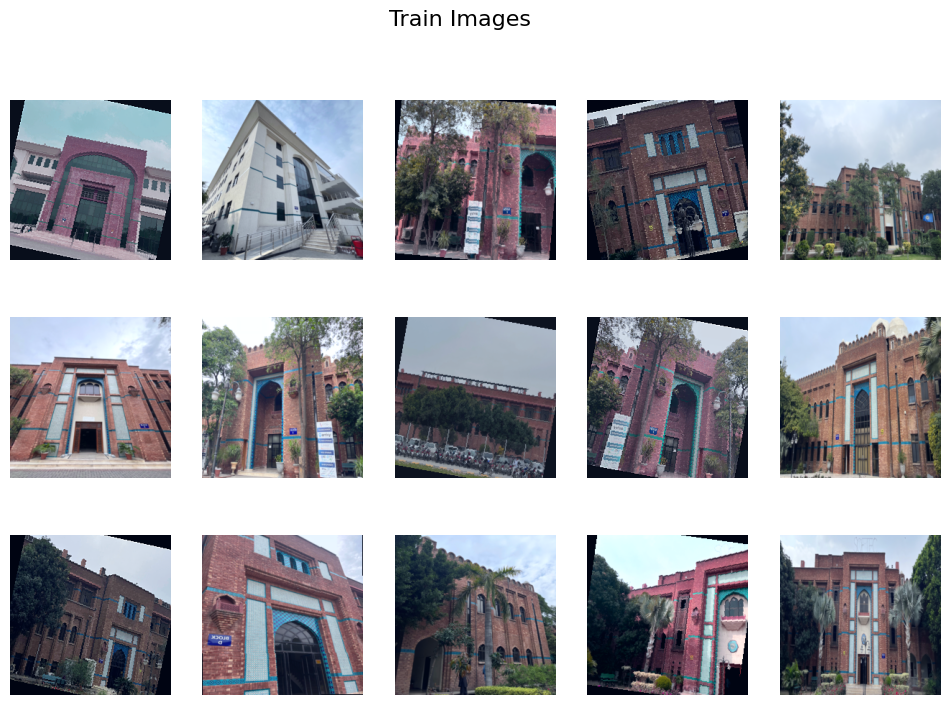

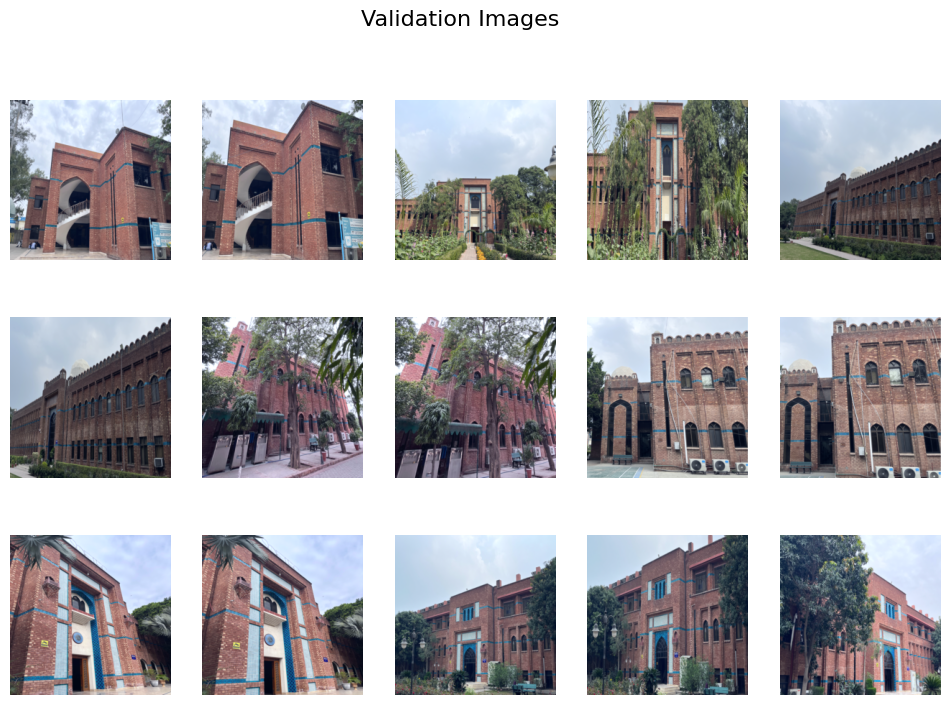

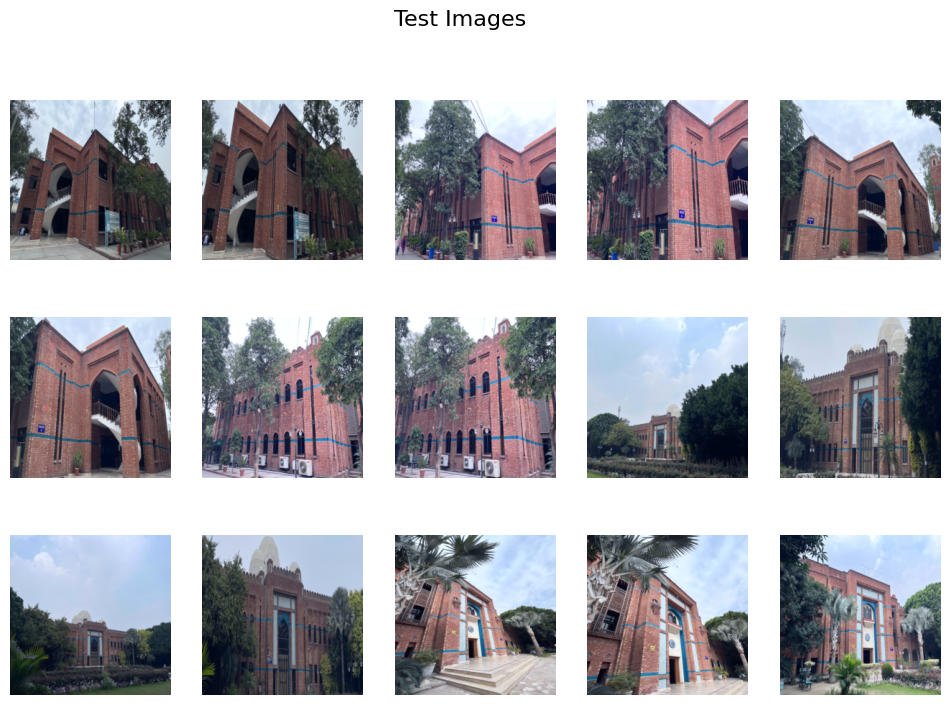

In [34]:
# Function to display images from a DataLoader
def show_images(dataloader, num_images=15, title="Images"):
    images_shown = 0
    fig, axes = plt.subplots(3, 5, figsize=(12, 8))  # 3 rows, 5 columns for 15 images
    axes = axes.flatten()

    for images, labels in dataloader:
        for i in range(images.size(0)):
            if images_shown >= num_images:
                plt.suptitle(title, fontsize=16)
                plt.show()
                return

            img = images[i].permute(1, 2, 0).numpy()  # Convert tensor to NumPy format
            img = img * 0.229 + 0.485  # Unnormalize (mean & std from normalization)
            img = img.clip(0, 1)  # Clip values for correct display

            axes[images_shown].imshow(img)
            axes[images_shown].axis("off")

            images_shown += 1

    plt.suptitle(title, fontsize=15)
    plt.show()

# Display 15 train images
show_images(train_loader, num_images=15, title="Train Images")

print("\n")

# Display 15 validation images
show_images(val_loader, num_images=15, title="Validation Images")

print("\n")

# Display 15 test images
show_images(test_loader, num_images=15, title="Test Images")


## Training

In [24]:
# Load pre-trained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Modify the classifier for 6 classes
num_classes = 6
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Move model to device
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [67]:
best_val_loss = float('inf') 
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)  # Sum loss across batch
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / total  # Average loss per sample

    
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)  # Sum loss across batch
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    val_loss /= total  # Average loss per sample
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model.pth")
        print("Model saved")


Epoch 1/10, Train Loss: 1.5921, Train Acc: 50.00%, Val Loss: 1.3630, Val Acc: 70.83%
Model saved
Epoch 2/10, Train Loss: 1.0322, Train Acc: 84.86%, Val Loss: 0.7889, Val Acc: 87.50%
Model saved
Epoch 3/10, Train Loss: 0.5468, Train Acc: 94.54%, Val Loss: 0.4226, Val Acc: 91.67%
Model saved
Epoch 4/10, Train Loss: 0.2699, Train Acc: 96.13%, Val Loss: 0.2413, Val Acc: 100.00%
Model saved
Epoch 5/10, Train Loss: 0.1421, Train Acc: 99.12%, Val Loss: 0.1279, Val Acc: 100.00%
Model saved
Epoch 6/10, Train Loss: 0.0725, Train Acc: 99.82%, Val Loss: 0.0971, Val Acc: 100.00%
Model saved
Epoch 7/10, Train Loss: 0.0620, Train Acc: 99.30%, Val Loss: 0.0688, Val Acc: 100.00%
Model saved
Epoch 8/10, Train Loss: 0.0541, Train Acc: 99.12%, Val Loss: 0.0515, Val Acc: 100.00%
Model saved
Epoch 9/10, Train Loss: 0.0267, Train Acc: 99.82%, Val Loss: 0.0487, Val Acc: 100.00%
Model saved
Epoch 10/10, Train Loss: 0.0207, Train Acc: 100.00%, Val Loss: 0.0427, Val Acc: 100.00%
Model saved


## Evaluation

In [68]:
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"Test Loss: {test_loss/len(test_loader):.4f} | Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.0293 | Test Accuracy: 100.00%


In [69]:
model.load_state_dict(torch.load("model.pth", weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [70]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [71]:
class_names = list(class_indices.keys()) 

# Classification Report
print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

     Block A       1.00      1.00      1.00         6
     Block B       1.00      1.00      1.00         6
     Block C       1.00      1.00      1.00         6
     Block D       1.00      1.00      1.00         6
     Block E       1.00      1.00      1.00         6
     Block F       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



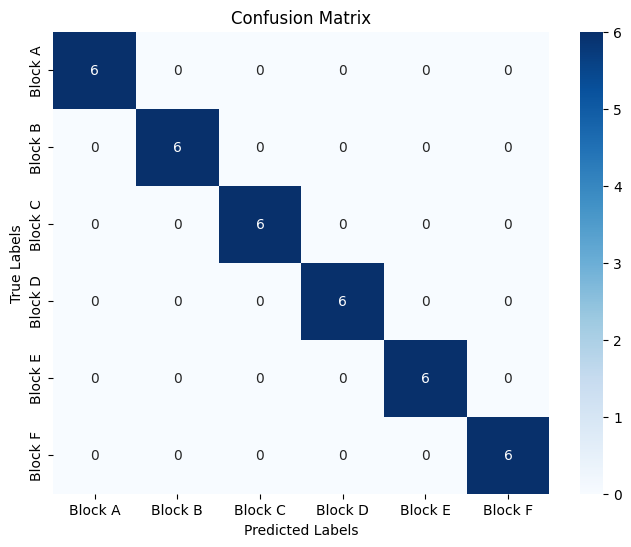

In [72]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


## Inference

In [ ]:
import torchvision.transforms as transforms
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [40]:
def apply_transformations(image_path):
    img = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = transform(img)
    return img.unsqueeze(0)  


In [62]:
label_mapping = {
    0: "Block A",
    1: "Block B",
    2: "Block C",
    3: "Block D",
    4: "Block E",
    5: "Block F", 
}


In [75]:
def predict_building(image):
    processed_image = apply_transformations(image)

    with torch.no_grad():
        output = model(processed_image.to(device))
        predicted_class = torch.argmax(output, dim=1).item()
    # print(f"Predicted Class: {predicted_class}")
    
    predicted_label = label_mapping.get(predicted_class, "Unknown")
    print(f"Predicted Building: {predicted_label}")

In [76]:
# Load pre-trained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Modify the classifier for 6 classes
num_classes = 6
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Load saved model weights
model.load_state_dict(torch.load("model.pth", weights_only=True))
model.eval()

# Move model to device
model = model.to(device)

print(f"Model Name: {model.__class__.__name__}")


Model Name: MobileNetV2


In [77]:
import matplotlib.pyplot as plt
from PIL import Image

In [87]:
img_1_path = "image_1.jpg"
img_2_path = "image_2.jpg"
img_3_path = "image_3.jpg"
img_4_path = "image_4.jpg"

In [88]:
img_1 = Image.open(img_1_path).convert("RGB")
img_2 = Image.open(img_2_path).convert("RGB")
img_3 = Image.open(img_3_path).convert("RGB")
img_4 = Image.open(img_4_path).convert("RGB")

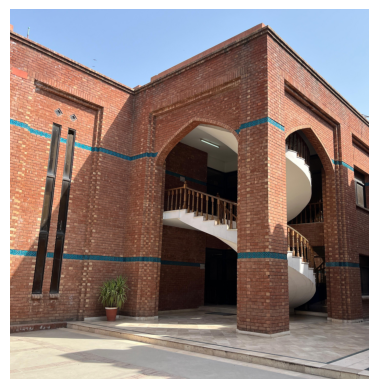

In [80]:
plt.imshow(img_1)
plt.axis('off')
plt.show()

In [81]:
print("Actual Building: Block A")
predict_building(img_1_path)

Actual Building: Block A
Predicted Building: Block A


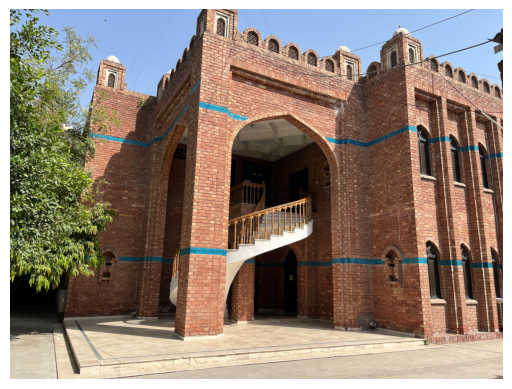

In [82]:
plt.imshow(img_2)
plt.axis('off')
plt.show()

In [83]:
print("Actual Building: Block E")
predict_building(img_2_path)

Actual Building: Block E
Predicted Building: Block E


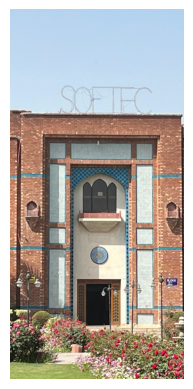

In [84]:
plt.imshow(img_3)
plt.axis('off')
plt.show()

In [86]:
print("Actual Building: Block C")
predict_building(img_3_path)

Actual Building: Block C
Predicted Building: Block C


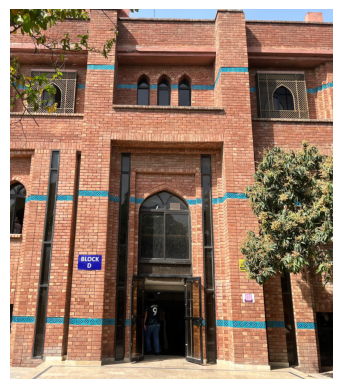

In [89]:
plt.imshow(img_4)
plt.axis('off')
plt.show()

In [91]:
print("Actual Building: Block D")
predict_building(img_4_path)

Actual Building: Block D
Predicted Building: Block D
